In [1]:
import os
os.chdir('./../')

In [24]:
import torch
import albumentations as A
import numpy as np
import pandas as pd
import timm
import torch.nn.functional as F
from collections import OrderedDict
from src.models.timm_classification_models import TimmDropOutBasicClassifier, TimmSNGPClassifier


In [3]:
device = 'cuda:0'

In [4]:
# import wandb
# run = wandb.init()
# artifact = run.use_artifact('nirschl-lab/sngp_isbi2/model-97wfp11w:v1', type='model')
# artifact_dir = artifact.download()

In [5]:
# artifact_dir

In [6]:
# Build the SAME architecture used in training
# model = TimmDropOutBasicClassifier(
#     model_name="resnet50",
#     num_classes=4,
#     pretrained=False,   # don't overwrite your trained head
#     in_chans=3,
#     drop_rate=0.2,
# )

model = TimmSNGPClassifier(model_name= 'resnet50',
  num_classes= 4,
  pretrained= True,
  in_chans= 3,
  reduction_dim= 512,
  drop_rate= 0.2,
  use_spec_norm= True, # required for TimmSNGPClassifier
  spec_norm_bound= 0.95, # required for TimmSNGPClassifier
  spec_norm_iteration= 1, # required for TimmSNGPClassifier
  covariance_likelihood= "gaussian", # kwarg for SNGP
  covariance_momentum= 0.999, # kwarg for SNGP
  normalize_input= True, # better performance when True
  output_bias_trainable= False, # kwarg for SNGP
  random_features= 1024, # kwarg for SNGP
  scale_random_features= True, # kwarg for SNGP
  trainable_kernel_scale= True # set True for tighter distribution around train data (based on make_moons tests); need to test ECE/OOD performance
)

# CKPT_PATH="artifacts/model-f4x06qkr:v0/model.ckpt"
CKPT_PATH="artifacts/model-97wfp11w:v1/model.ckpt"

ckpt = torch.load(CKPT_PATH, map_location="cuda", weights_only=False)
state_dict = ckpt.get("state_dict", ckpt)

def remap(k: str) -> str:
    # Most specific first
    if k.startswith("net.model."):
        return "model." + k[len("net.model."):]
    if k.startswith("net."):
        return k[len("net."):]              # e.g., "net.layer1..." -> "layer1..."
    if k.startswith("module."):
        return k[len("module."):]           # DDP wrapper
    return k

new_state = OrderedDict((remap(k), v) for k, v in state_dict.items())

missing, unexpected = model.load_state_dict(new_state, strict=False)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


2025-10-21 13:34:10.499 | DEBUG    | src.models.timm_classification_models:__init__:159 - Applying spectral normalization to backbone


Missing keys: []
Unexpected keys: []


TimmSNGPClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (drop_block): Identity()
        (act2): ReLU(inplace=True)
        (aa): Identity()
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps

In [73]:
# features = {}

# def hook_fn(module, input, output):
#     features['reduced'] = output

# handle = model.sngp_classifier.reduce_dim_layer.register_forward_hook(hook_fn)
# _ = model(images.to('cuda'))  # forward pass
# handle.remove()

# print(features['reduced'].shape)  # your reduced feature tensor

In [4]:
# import torch
# x = torch.randn(100, 3, 224, 224)
# with torch.no_grad():
#     l = model(x)
# print(out.shape)  # should be [1, 8]


In [6]:
# with torch.no_grad():
#     probs2 = torch.softmax(torch.tensor(logits), dim=1)[:, 0].detach().numpy()
# torch.softmax(torch.tensor(logits), dim=1).shape

In [ ]:

# tang_data = load_dataset("nirschl-lab/acevedo_et_al_2020")


In [7]:
# Custom Dataset wrapper
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from datasets import load_dataset
class HFDataset(Dataset):
    def __init__(self, hf_dataset, transform=None, fold=None):
        self.dataset = hf_dataset
        self.transform = transform
        self.fold = fold

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        try:
            image = item['image']  # PIL Image
            label = item['label']
            mask = item.get('mask', None)  # Optional mask
            if mask is not None:
                mask = torch.tensor(mask, dtype=torch.float32)

            image_id = item['image_id']
        except TypeError as e:
            raise
        if self.transform:
            # Apply transformations
            if isinstance(self.transform, A.Compose):
                # Albumentations expects numpy arrays
                image_np = np.array(image)
                transformed = self.transform(image=image_np, mask=mask)
                if mask is not None:
                    raise NotImplementedError("Mask augmentation is not yet returned")
                    #image, mask = transformed['image'], transformed['mask']
                else:
                    image = transformed['image']
            else:
                image = self.transform(image)

        return image_id, image, label, self.fold

In [39]:

test_transform = A.Compose(
  [
    A.Resize(height=256, width=256, p=1.0),
    A.CenterCrop(height=224, width=224, p=1.0),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255.0),
    A.pytorch.transforms.ToTensorV2(p=1.0)
  ]
)


dataset_name = "nirschl-lab/tang_et_al_2019"
# dataset_name = "nirschl-lab/wong_et_al_2022"
eval_train = HFDataset(load_dataset(dataset_name)['train'],
                                transform=test_transform, fold='train')

In [40]:
dataloader = DataLoader(eval_train, batch_size=32, shuffle=False, num_workers=4)


In [48]:
#get the output of last layer before classification head and map to PCA and plot
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
# b --- IGNORE ---
# Extract features using the model
model.eval()
model = model.to('cuda')

# Collect features from multiple batches
image_ids_all = []
features_all = []
probs_all = []
targets_all = []
fold_all = []


def hook_fn(module, input, output):
    features['reduced'] = output

with torch.no_grad():
    for batch_idx, batch in enumerate(dataloader):
        # print(batch_idx)
        image_ids, images, labels, folds = batch
        
        # Get features from backbone (before classification head)
        # This gives you the 2048-dimensional features after global average pooling
        # features = model.backbone.forward_features(images.to('cuda'))
        # features = model.forward_features(images.to('cuda'))
        # break

        features = {}
        handle = model.sngp_classifier.reduce_dim_layer.register_forward_hook(hook_fn)
        out = model(images.to('cuda'))  # forward pass
        handle.remove()
        features = features['reduced']
        probs = F.softmax(out, dim=1)
        
        # If features are 4D (batch, channels, height, width), apply global average pooling
        if len(features.shape) == 4:
            features = features.mean(dim=[2, 3])  # Global average pooling
        image_ids_all.extend(image_ids)
        features_all.append(features)
        targets_all.append(labels)
        probs_all.append(probs)
        fold_all.append(folds)

        
        # Limit to first few batches for demonstration
        if batch_idx >= 10:  # Adjust as needed
            break
# Concatenate all features and labels
# features = np.concatenate(features_all, axis=0)
# labels = np.concatenate(labels_all, axis=0)
features = torch.cat(features_all).cpu().numpy()  # n x 2048
probs_all = torch.cat(probs_all).cpu().numpy() # n x C
targets = torch.cat(targets_all).cpu().numpy() # N x 1 (0-C)
prediction_prob_score = np.max(probs_all, axis=1)
prediction = np.argmax(probs_all, axis=-1)

print(f"Features shape: {features.shape}")  # Should be (n_samples, 2048)
print(f"Labels shape: {targets.shape}")

# b --- IGNORE ---

Features shape: (352, 128)
Labels shape: (352,)


In [49]:
# Standardize features before PCA
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply PCA with 2 components
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

In [50]:
pca_x = features_pca[:, 0]
pca_y = features_pca[:, 1]


In [51]:
data_dict = {
                'image_id': image_ids_all,
                'target': targets,
                'prediction': prediction,
                'prediction_prob_score': prediction_prob_score,
                'class_probs': probs_all.tolist(),
                'pca_x': pca_x.tolist(),
                'pca_y': pca_y.tolist()
            }

In [52]:
for key, value in data_dict.items():
    print(f"{key}: {type(value)}, length: {len(value)}")

image_id: <class 'list'>, length: 352
target: <class 'numpy.ndarray'>, length: 352
prediction: <class 'numpy.ndarray'>, length: 352
prediction_prob_score: <class 'numpy.ndarray'>, length: 352
class_probs: <class 'list'>, length: 352
pca_x: <class 'list'>, length: 352
pca_y: <class 'list'>, length: 352


In [53]:
pca_csv = pd.DataFrame(data_dict)

In [54]:
pca_csv.head()

,image_id,target,prediction,prediction_prob_score,class_probs,pca_x,pca_y
0,6774146b-822a-45a1-abf8-56fe624ac1a8,2,2,0.993602,"[0.00034115416929125786, 0.00202148943208158, ...",1.444342,5.708894
1,47d1cd60-cb3f-4fd7-95fa-bf177873b2cf,2,2,0.994258,"[0.0005385391996242106, 0.00259707635268569, 0...",4.434662,7.186531
2,02941d5d-4937-4e2d-9f08-8a78bef3b151,1,1,0.819415,"[0.014072814024984837, 0.8194153904914856, 0.1...",2.427430,-14.419143
3,f5c5de8a-c985-4ad5-8edb-ecc2d1c3ba4d,0,0,0.873740,"[0.8737396001815796, 0.04609234258532524, 0.03...",-11.039298,-7.660652
4,d0b547b5-3f2c-4685-9c4f-0f0738db07de,2,2,0.987120,"[0.0005588829517364502, 0.009210443124175072, ...",5.671434,1.299591


In [55]:
pca_csv.to_csv("csv/tang_et_al_2019_sngp_pca_features.csv", index=False)

In [41]:
tang_et_al_2019 = {'caa': 0, 'cored': 1, 'diffuse': 2, 'negative': 3}
tang_ix_to_classes = {value:key for key, value in tang_et_al_2019.items()}

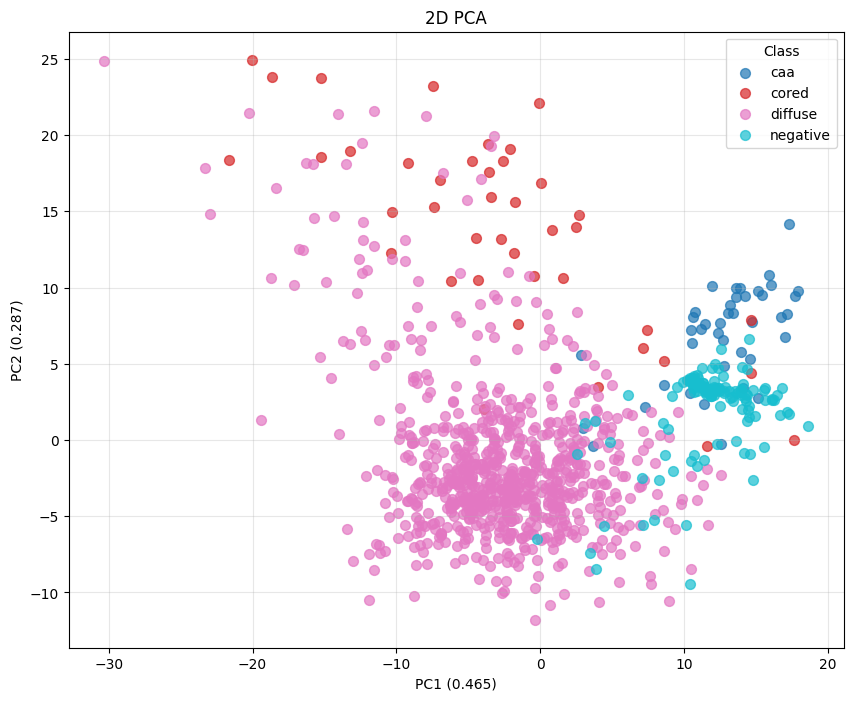

Total explained variance: 0.752


In [63]:
# Standardize features before PCA
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply PCA with 2 components
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

# Create 2D PCA plot with proper legend
plt.figure(figsize=(10, 8))

# Create scatter plot for each class separately to have proper legend
unique_labels = np.unique(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask = labels == label
    plt.scatter(features_pca[mask, 0], features_pca[mask, 1], 
               c=[colors[i]], label=tang_ix_to_classes[label], 
               alpha=0.7, s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')
plt.title('2D PCA')
plt.legend(title='Class')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

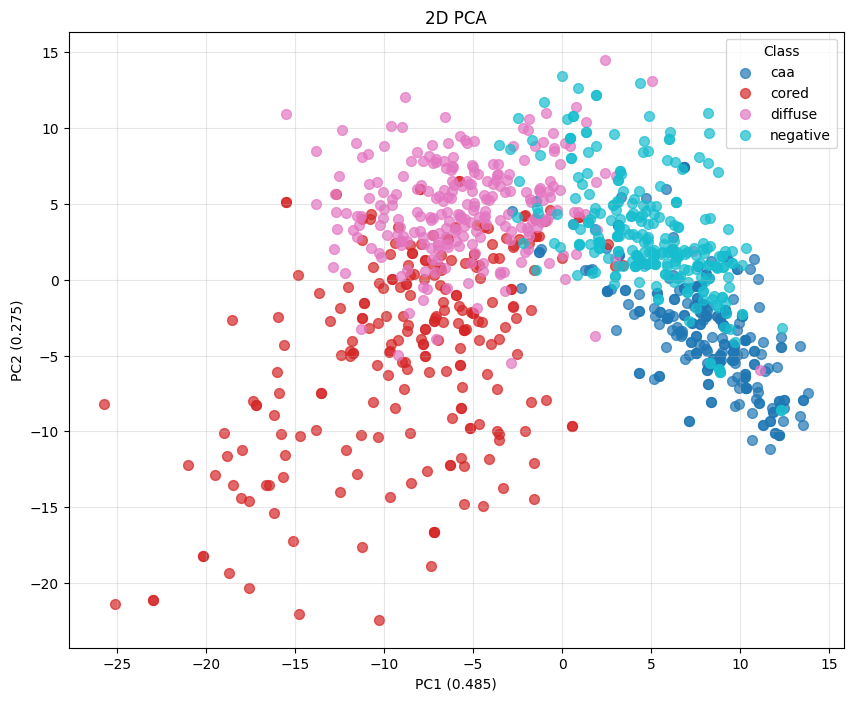

Total explained variance: 0.760


In [70]:
# Standardize features before PCA
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply PCA with 2 components
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

# Create 2D PCA plot with proper legend
plt.figure(figsize=(10, 8))

# Create scatter plot for each class separately to have proper legend
unique_labels = np.unique(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask = labels == label
    plt.scatter(features_pca[mask, 0], features_pca[mask, 1], 
               c=[colors[i]], label=tang_ix_to_classes[label], 
               alpha=0.7, s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')
plt.title('2D PCA')
plt.legend(title='Class')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

In [ ]:
# test:
#   _target_: albumentations.Compose
#   transforms:
#     - _target_: albumentations.Resize
#       height: 256
#       width: 256
#       p: 1.0

#     - _target_: albumentations.CenterCrop
#       height: 224
#       width: 224
#       p: 1.0

#     - _target_: albumentations.Normalize
#       mean: [0.485, 0.456, 0.406]
#       std:  [0.229, 0.224, 0.225]
#       max_pixel_value: 255.0

#     - _target_: albumentations.pytorch.transforms.ToTensorV2
#       p: 1.0